In [2]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
import sys
sys.path.append('../python')
import utils
import threepoint

In [3]:
from astropy.io import fits

In [4]:
blind = False
file1 = '../output/blind-metacal-updatedcov/des-y3-2pt-blind-metacal-simcov.txt'
file2 = '../output/blind-metacal-8arcmincut-december/des-y3-2pt-map3-all-blind-metacal.txt'
files = [file1, file2]
chains = utils.read_cosmosis_mcmc_des_blind_chains(files, to_mcsamples=True)
desy3_2ptonly, desy3_joint = chains[0], chains[1]

../output/blind-metacal-updatedcov/des-y3-2pt-blind-metacal-simcov.txt
8
Blinding  ['om', 'h0', 'ob', 'ns', 's8', 'mnu', 'sig8', 'COSMOLOGICAL_PARAMETERS--SIGMA_12']
Removed no burn in
../output/blind-metacal-8arcmincut-december/des-y3-2pt-map3-all-blind-metacal.txt
Blinding  ['om', 'h0', 'ob', 'ns', 's8', 'mnu', 'sig8', 'COSMOLOGICAL_PARAMETERS--SIGMA_12']
Removed no burn in


In [5]:
desy3_2ptonly = utils.read_cosmosis_mcmc_des_chain('../output/blind-metacal-updatedcov/des-y3-2pt-blind-metacal-simcov.txt', to_mcsamples=True, blind=blind)
desy3_joint = utils.read_cosmosis_mcmc_des_chain('../output/blind-metacal-8arcmincut-december/des-y3-2pt-map3-all-blind-metacal.txt', to_mcsamples=True, blind=blind)

Removed no burn in
Removed no burn in


In [6]:
print(desy3_2ptonly.getMeans())

[ 3.52645854e-01  7.06829497e-01  4.77132586e-02  9.58511396e-01
  7.60384271e-01  3.24867492e-01 -6.26318000e-03 -2.16473131e-02
 -2.23298471e-02 -3.70154722e-02  2.14289124e-03 -1.52670714e-02
  6.41692731e-03 -4.79480235e-03 -4.88142094e-02  2.01442653e+00
  7.10632231e-01  6.83358313e-01  4.30861293e+02             nan
  2.99702888e+01 -6.58664129e+00  2.33836475e+01  3.34505095e-04]


In [7]:
print(desy3_joint.getMeans())

[ 2.73859312e-01  7.58555441e-01  4.36926338e-02  9.63863327e-01
  7.89742469e-01  2.63057514e-01 -5.87736958e-03 -2.21175708e-02
 -2.32803307e-02 -3.61818205e-02  6.96653158e-03 -1.42430323e-02
  5.39263193e-03 -4.39672913e-03 -3.20054025e-01  2.33394373e+00
  8.33135576e-01  7.65616626e-01  4.37373422e+02  7.51173247e+01
  3.00516334e+01 -3.81743594e+01 -8.12272597e+00  3.23286656e-04]


In [18]:
from getdist import plots

# Assuming desy3_joint is your MCSamples instance
#param1, param2 = 'om', 's8'
#param1, param2 = 's8', 'a1'
param1, param2 = 'om', 'a1'

# Get 2D marginalized posterior
density = desy3_joint.get2DDensityGridData(param1, param2)

# Access the grid of probabilities and corresponding parameter values
x, y = density.x, density.y  # parameter grid values
prob = density.P  # 2D posterior probabilities

In [19]:
import numpy as np

# Find the indices of the maximum probability
max_idx = np.unravel_index(np.argmax(prob), prob.shape)

# Get the parameter values corresponding to the peak
peak_x = x[max_idx[0]]
peak_y = y[max_idx[1]]

print(f"Peak of the 2D posterior: {param1} = {peak_x}, {param2} = {peak_y}")

Peak of the 2D posterior: om = 0.3274509803921569, a1 = -1.2796427011064626


In [20]:
density2pt = desy3_2ptonly.get2DDensityGridData(param1, param2)

# Access the grid of probabilities and corresponding parameter values
x2pt, y2pt = density2pt.x, density2pt.y  # parameter grid values
prob2pt = density2pt.P  # 2D posterior probabilities
max_idx_2pt = np.unravel_index(np.argmax(prob2pt), prob2pt.shape)

# Get the parameter values corresponding to the peak
peak_x = x2pt[max_idx_2pt[0]]
peak_y = y2pt[max_idx_2pt[1]]

print(f"Peak of the 2D posterior: {param1} = {peak_x}, {param2} = {peak_y}")

Peak of the 2D posterior: om = 0.31647058823529417, a1 = 0.9631035292711747


In [17]:
print(np.sqrt((0.27725490196078434 - 0.36039215686274517)**2 + (0.7867450980392157 - 0.7587450980392156)**2))

0.08772572685725444


In [16]:
print(np.sqrt((0.7757647058823529 - 0.780156862745098)**2 + (-0.9392362469380346 - 0.5950982047083597)**2))

1.5343407380862144


In [21]:
print(np.sqrt((0.31647058823529417 - 0.3274509803921569)**2 + (-1.2796427011064626 - 0.9631035292711747)**2))

2.24277310998795


In [144]:
param_names_joint = desy3_2ptonly.getParamNames().names
mean_joint = desy3_2ptonly.getMeans()
sigma_joint = [desy3_2ptonly.std([param]) for param in param_names_joint]
print(sigma_joint)

[array([0.06225354]), array([0.08331086]), array([0.00989794]), array([0.05011306]), array([0.02190583]), array([0.14504663]), array([0.00791831]), array([0.00696792]), array([0.00673676]), array([0.00663381]), array([0.01330129]), array([0.01082614]), array([0.00907775]), array([0.01359406]), array([0.40896273]), array([1.98780958]), array([0.07560692]), array([0.06179732]), array([6.52118366]), array([nan]), array([1.65149631]), array([1.54248438]), array([1.93742213]), array([0.00012635])]


In [112]:
measurement = fits.open("../data/dv/real_map3_desy3_blind_DECEMBER_8arcmincut.fits")
bestfit_joint = fits.open("../data/dv/bestfit-y3blind-jointcosmo-map3.fits")
bestfit_2pt = fits.open("../data/dv/bestfit-y3blind-2ptcosmo-map3.fits")

In [113]:
meas = np.ones(80)
bfjoint_vals = np.ones(80)
bf2pt_vals = np.ones(80)
for i in range(80):
    meas[i] = measurement[1].data[i][6]
    bf2pt_vals[i] = bestfit_2pt[1].data[i][6]
    bfjoint_vals[i] = bestfit_joint[1].data[i][6]

In [134]:
print(bf2pt_vals/meas)

[0.39803207 0.57289481 0.32591245 1.68459095 0.48967371 0.89818053
 0.57432561 1.0824512  0.43938612 0.6021008  0.52495084 0.79104462
 0.37140302 0.50183664 0.50397068 0.56158215 0.74081166 1.1997151
 1.61934756 0.96103983 0.65912144 0.6352937  0.77495781 0.91958411
 1.00101737 0.6111749  0.64563725 0.71651602 1.06840351 1.04250565
 0.59571548 0.7588839  0.86794507 0.49296074 0.50038875 0.53883238
 0.48602178 0.36397723 0.43727601 0.37618954 1.32630603 1.41836389
 0.67634946 1.05906399 0.7209948  0.73172067 0.5914569  0.76263244
 0.49676241 0.56803917 0.61981781 0.78262153 0.75524249 0.75712876
 0.57202871 0.55153988 0.73978388 0.54326265 0.54176181 0.98017219
 0.786099   0.62492148 0.52503783 1.06278776 0.77405432 0.67161812
 0.74603059 0.65034214 0.87972567 0.85010735 0.67811157 0.66927779
 0.52754308 0.59771381 0.48392265 0.5023697  0.53903954 0.71617577
 0.51806717 0.70135821]


In [135]:
print(bfjoint_vals/meas)

[0.56629908 0.83500592 0.47926755 2.47448289 0.69229135 1.29954696
 0.83571664 1.56876659 0.63178307 0.88192729 0.77051406 1.15418548
 0.53745203 0.73874214 0.74283269 0.8225944  1.03752763 1.71614641
 2.3192935  1.36616269 0.93891821 0.91900249 1.11735966 1.31333705
 1.43614522 0.88887584 0.93505404 1.02766811 1.5498081  1.52468601
 0.86379611 1.08800635 1.26938378 0.72527994 0.7291795  0.77634468
 0.71705121 0.53887677 0.64058485 0.54494504 1.83156234 1.99343018
 0.94599618 1.4644936  1.01155745 1.03700488 0.8294761  1.05541503
 0.70251752 0.80964233 0.87333296 1.08814615 1.07605083 1.07921151
 0.80152436 0.76154962 1.06354807 0.77911031 0.76296165 1.36067583
 1.14118747 0.90211201 0.74355847 1.48442916 1.11563388 0.95597977
 1.03565944 0.88917577 1.27986522 1.21666094 0.9455456  0.91988136
 0.77518231 0.86021955 0.67795893 0.69454608 0.80009219 1.03570231
 0.72881324 0.97530349]


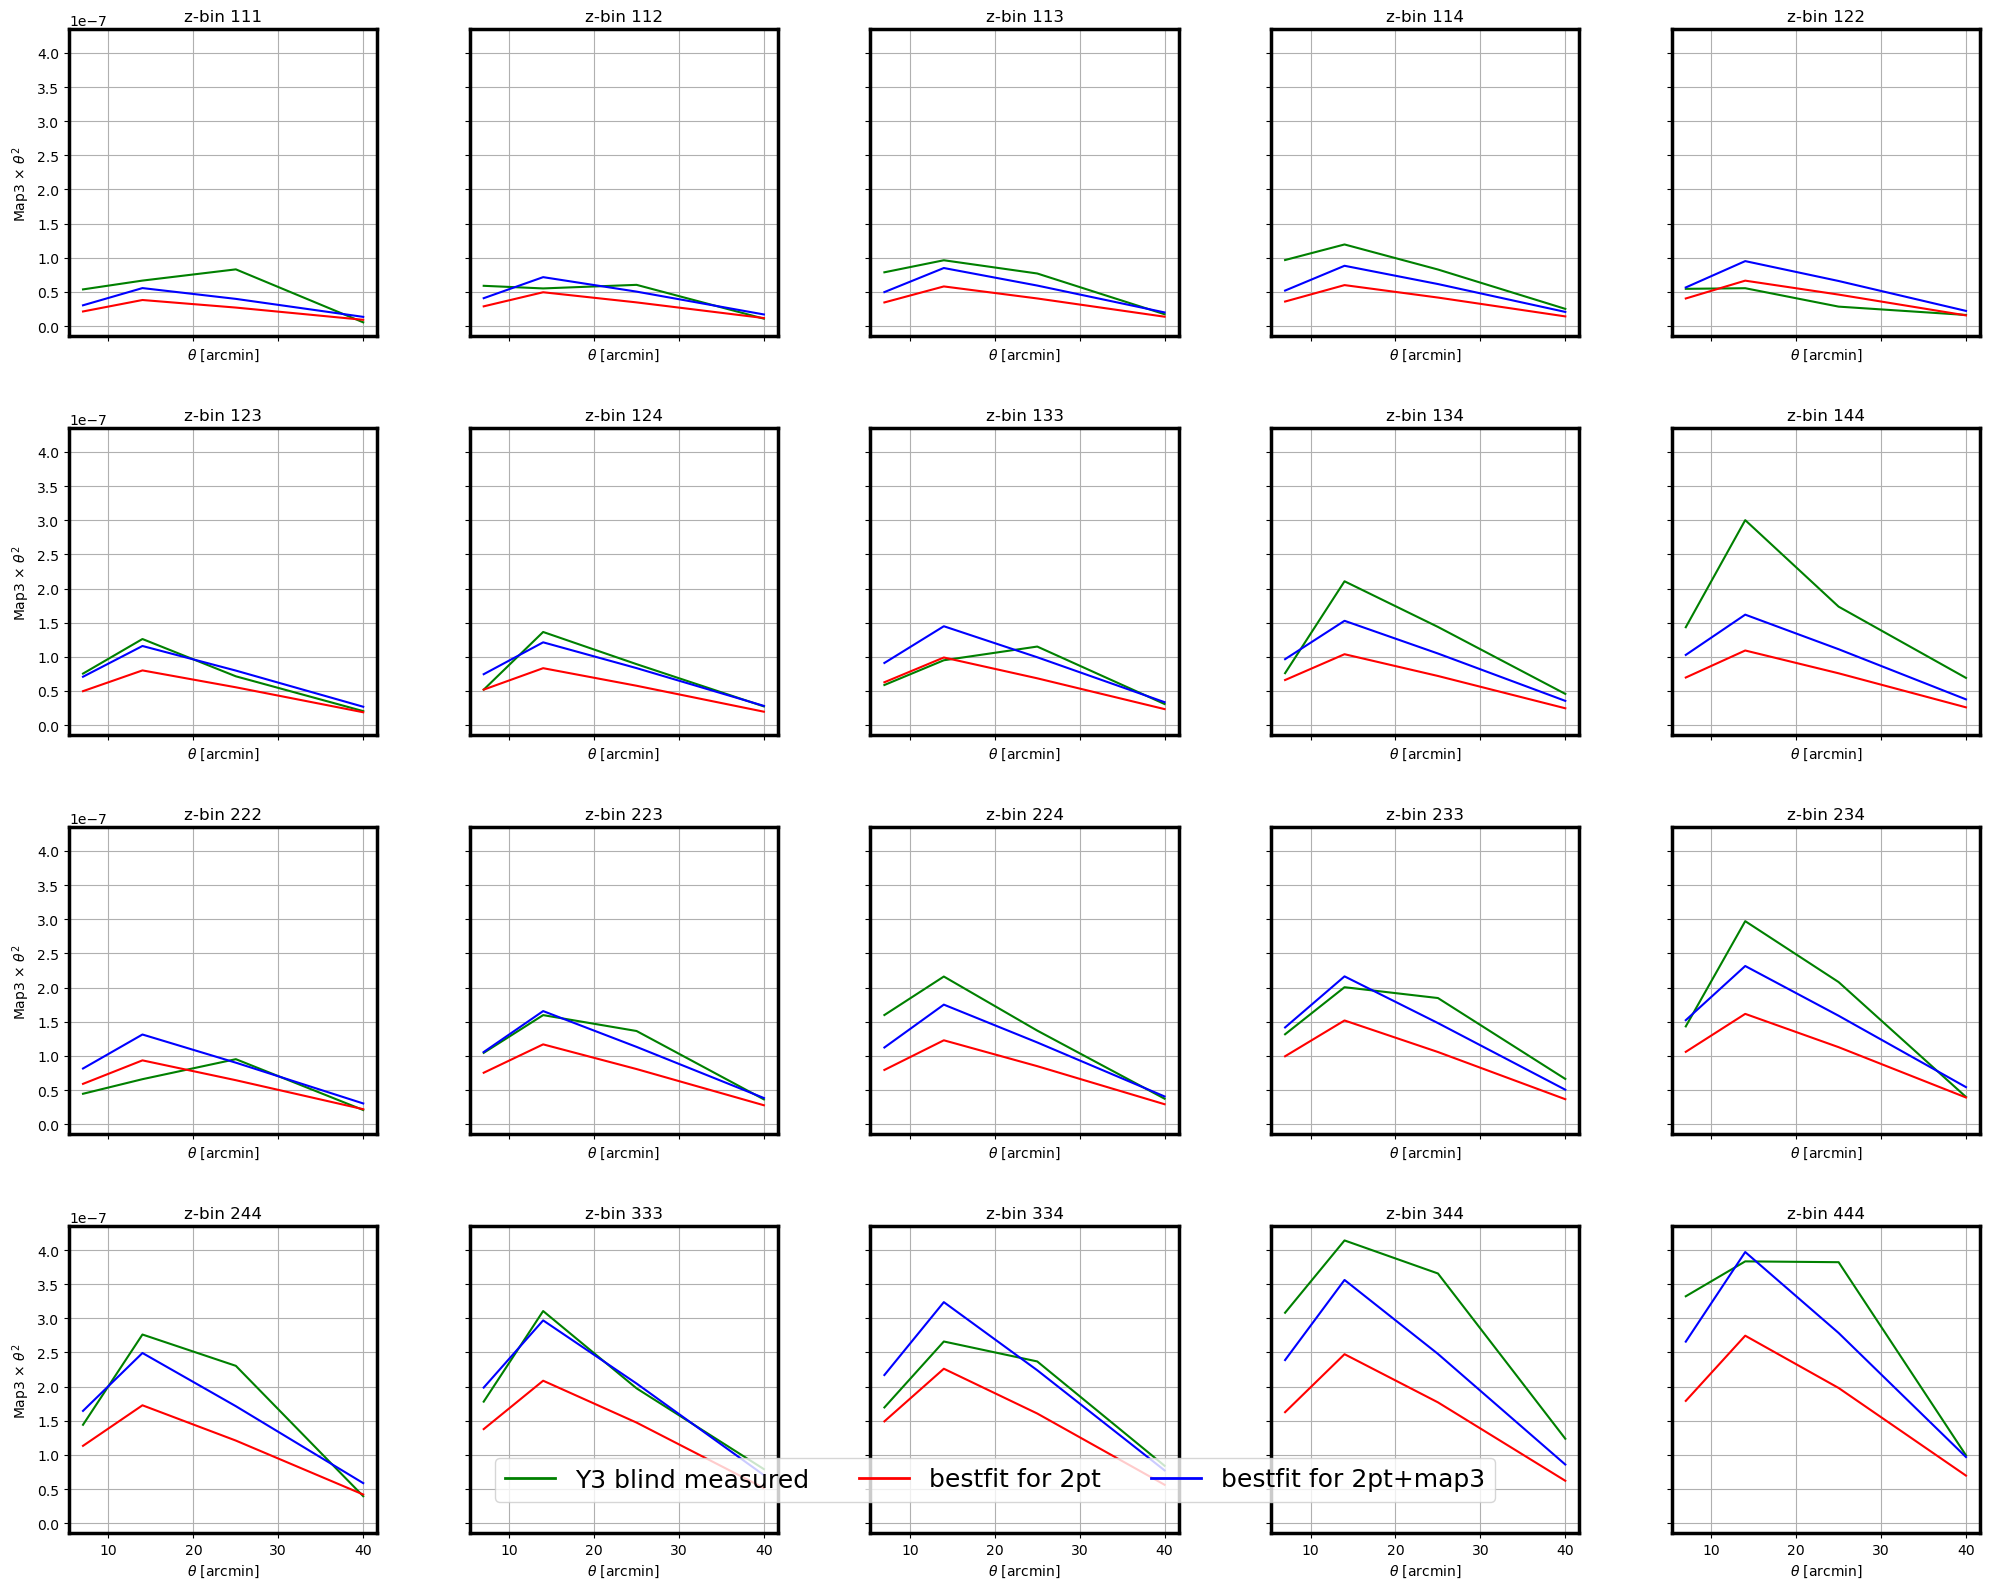

In [141]:
x_values = np.array([7, 14, 25, 40])

# Define z-bin combinations
z_bin_combinations = [
    "111", "112", "113", "114", "122", "123", "124", 
    "133", "134", "144", "222", "223", "224", 
    "233", "234", "244", "333", "334", "344", "444"
]

# Split data vector into 20 sections (4 values each)
sections = [meas[i * 4:(i + 1) * 4] for i in range(20)]
sections_bf2pt = [bf2pt_vals[i * 4:(i + 1) * 4] for i in range(20)]
sections_bfjoint = [bfjoint_vals[i * 4:(i + 1) * 4] for i in range(20)]

# Create subplots
fig, axes = plt.subplots(4, 5, figsize=(20, 16), sharey=True, sharex=True)

# Flatten axes for easier iteration
axes = axes.flatten()

# Plot each section
for i, ax in enumerate(axes):
    y_values = sections[i]
    y_values_bf2pt = sections_bf2pt[i]
    y_values_bfjoint = sections_bfjoint[i]
    ax.plot(x_values, y_values*x_values**2, linestyle='-', label=f'z-bin {z_bin_combinations[i]}', color='g')
    ax.plot(x_values, y_values_bf2pt*x_values**2, linestyle='-', label=f'z-bin {z_bin_combinations[i]}', color='r')
    ax.plot(x_values, y_values_bfjoint*x_values**2, linestyle='-', label=f'z-bin {z_bin_combinations[i]}', color='b')
    ax.set_title(f'z-bin {z_bin_combinations[i]}', fontsize=12)
    ax.set_xlabel(r'$\theta$ [arcmin]', fontsize=10)
    if i % 5 == 0:  # Add y-label to the first column of plots
        ax.set_ylabel(r'Map3 $\times$ $\theta^2$', fontsize=10)
    ax.grid()

    # Thicker borders (spines)
    for spine in ax.spines.values():
        spine.set_linewidth(2.5)
        
lines = [
    plt.Line2D([0], [0], color='g', lw=2, label='Y3 blind measured'),
    plt.Line2D([0], [0], color='r', lw=2, label='bestfit for 2pt'),
    plt.Line2D([0], [0], color='b', lw=2, label='bestfit for 2pt+map3')
]
fig.legend(
    handles=lines, 
    loc='lower center', 
    bbox_to_anchor=(0.5, 0.05),  # Position above the figure
    ncol=3, 
    fontsize=18
)

# Adjust layout for square plots and spacing
plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)  # Adjust as needed for spacing
plt.savefig('../plots/map3_y3blind_measured_and_bestfit.pdf', dpi=500)
#plt.show()

In [120]:
twmeasurement = fits.open("../data/dv/blind-metacal-2pt-DESY3.fits")
twbestfit_joint = fits.open("../data/dv/bestfit-y3blind-jointcosmo-2pt.fits")
twbestfit_2pt = fits.open("../data/dv/bestfit-y3blind-2ptcosmo-2pt.fits")

In [129]:
xipxim = np.ones(400)
xipxim_bf2pt = np.ones(400)
xipxim_bfjoint = np.ones(400)

for i in range(200):
    xipxim[i] = twmeasurement[2].data[i][3]
    xipxim_bf2pt[i] = twbestfit_2pt[2].data[i][3]
    xipxim_bfjoint[i] = twbestfit_joint[2].data[i][3]
for i in range(200,400):
    xipxim[i] = twmeasurement[3].data[i-200][3]
    xipxim_bf2pt[i] = twbestfit_2pt[3].data[i-200][3]
    xipxim_bfjoint[i] = twbestfit_joint[3].data[i-200][3]  
    
ratiobf2pt = xipxim_bf2pt/xipxim
ratiobfjoint = xipxim_bfjoint/xipxim

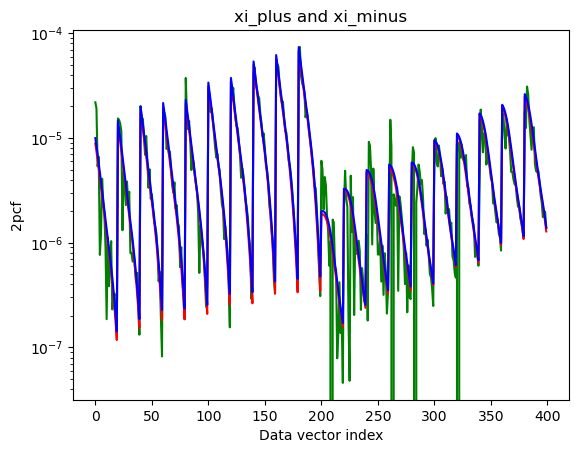

In [130]:
plt.title('xi_plus and xi_minus')
plt.yscale('log')
plt.plot(np.arange(400), xipxim, color='g', label = 'blind measured')
plt.plot(np.arange(400), xipxim_bf2pt, color='r', label = 'bestfit 2pt')
plt.plot(np.arange(400), xipxim_bfjoint, color='b', label = 'bestfit joint')
plt.xlabel('Data vector index')
plt.ylabel('2pcf')
plt.show()
#plt.savefig('../plots/2pcf_y3blind_measured_and_bestfit.pdf', dpi=500)

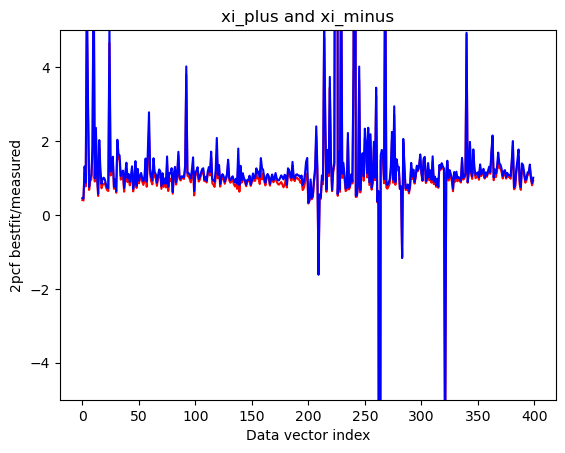

In [133]:
plt.title('xi_plus and xi_minus')
#plt.yscale('log')
plt.plot(np.arange(400), ratiobf2pt, color='r', label = 'bestfit 2pt')
plt.plot(np.arange(400), ratiobfjoint, color='b', label = 'bestfit joint')
plt.xlabel('Data vector index')
plt.ylabel('2pcf bestfit/measured')
plt.ylim(-5,5)
plt.show()

In [137]:
print(ratiobfjoint)

[  0.4545787    0.44059607   1.31171791   0.8746298    6.1724264
   3.19521962   0.75631809   1.02488311   1.06884977   1.84351734
   7.26642555   0.99158927   2.35678395   1.12166618   0.57018712
   2.02464335   1.22637683   0.8379173    0.98126755   1.00832741
   0.95368753   0.82364133   0.73778715   0.71787121   5.14158704
   1.1742699    1.20993557   1.57493356   0.76297626   0.97128124
   0.64353957   2.03355379   1.64302705   1.61165293   1.05223586
   1.14071633   1.19910709   0.72826312   1.13218035   1.41266045
   0.98954536   1.10352519   0.89400546   1.06169266   1.31457865
   0.70321739   0.97077853   1.4553784    0.79376537   1.24633542
   0.92649305   1.0446704    1.13604949   0.99638342   0.91133253
   1.03816927   1.52747524   0.90336995   1.75298767   2.77674283
   1.24292249   1.01688485   0.93183489   1.53333248   1.1603878
   1.10509053   0.87085082   1.06761829   1.23047869   1.17840555
   0.77400085   1.12676535   0.84357361   0.9860325    0.8439556
   1.58144647